In [2]:
import numpy as np
import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

(X_train, Y_train), (X_test, Y_test)= fashion_mnist.load_data()

print(f"Original X_train shape: {X_train.shape}")

X_train = np.array(X_train)
Y_train = np.array(Y_train)
X_test = np.array(X_test)
Y_test = np.array(Y_test)

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

Y_train = keras.utils.to_categorical(Y_train, 10)
Y_test = keras.utils.to_categorical(Y_test, 10)
print('Training data:')
print(Y_train.shape)
print(X_train.shape)
print('------------------')
print('Testing Data:')
print(X_test.shape)
print(Y_test.shape)

#Model

model = Sequential()
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D((3,3)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D((3,3)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=20)

pred = model.predict(X_test[0:10])
print('Predicted value: ', np.argmax(pred[7]))
print('Acutal value: ', np.argmax(Y_test[7]))


Original X_train shape: (60000, 28, 28)
Training data:
(60000, 10)
(60000, 28, 28, 1)
------------------
Testing Data:
(10000, 28, 28, 1)
(10000, 10)
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7914 - loss: 0.5699
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8613 - loss: 0.3806
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8787 - loss: 0.3307
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8888 - loss: 0.3053
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8950 - loss: 0.2847
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9020 - loss: 0.2701
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9057 - loss: 0.2571
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9109 - loss: 0.2453
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9144 - loss: 0.2335
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - a

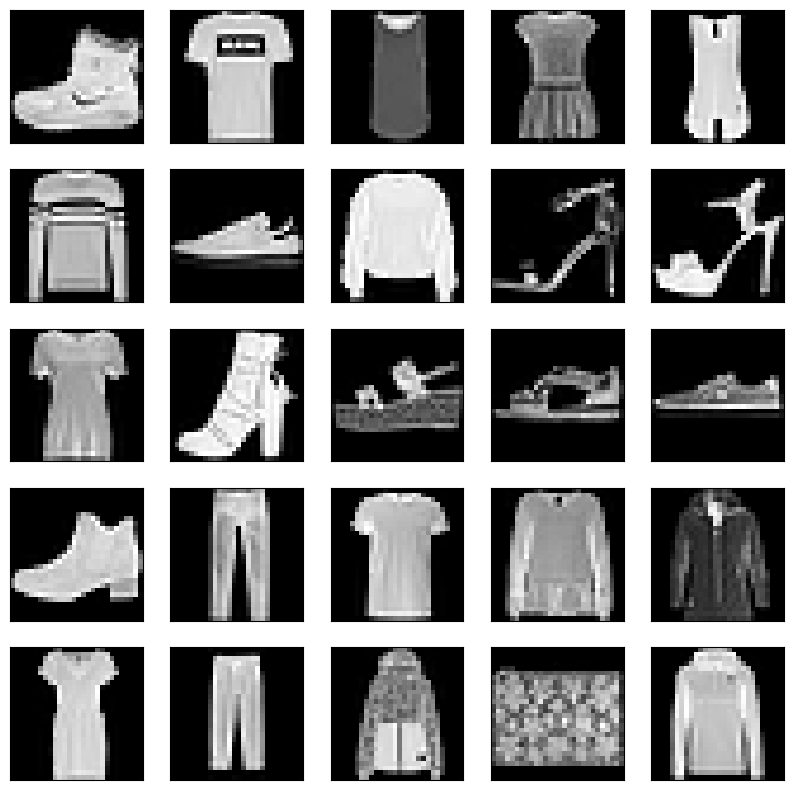

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='gray')
plt.show()

In [4]:
model = Sequential()
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D((3,3)))
model.add(Conv2D(32, (3,3), activation='tanh'))
model.add(MaxPool2D((3,3)))
model.add(Flatten())
model.add(Dense(64, activation='tanh'))
model.add(Dense(10, activation='sigmoid'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, Y_train, epochs=2)

pred = model.predict(X_test[0:3])
print(pred)
print(Y_test[3])

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8131 - loss: 0.5191
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8743 - loss: 0.3446
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.09384796 0.01528202 0.05377598 0.10357504 0.01720226 0.98144025
  0.1021687  0.9949396  0.43767744 0.9999534 ]
 [0.76055163 0.03072767 0.9998342  0.2173346  0.9710545  0.07517715
  0.9175326  0.01738541 0.6926047  0.08795702]
 [0.7201551  0.9999859  0.2772345  0.94685453 0.83202577 0.31570566
  0.4705418  0.00720512 0.19235465 0.16788042]]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [5]:
a = [11,21,33,45]